In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from hmmlearn import hmm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib as mpl
from matplotlib import font_manager
import math
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [36]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))

In [37]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df

In [38]:
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())

In [39]:
def train(X_train, y_train, X_val, y_val):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        n_components = trial.suggest_int('n_components', 2, 10)
        covariance_type = trial.suggest_categorical('covariance_type', ['full', 'tied', 'diag', 'spherical'])
        n_iter = trial.suggest_int('n_iter', 50, 200)
        
        # 数据清理：处理NaN值
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='mean')
        X_train_imputed = imputer.fit_transform(X_train)
        X_val_imputed = imputer.transform(X_val)
        
        # 数据标准化
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_imputed)
        X_val_scaled = scaler.transform(X_val_imputed)
        
        # PCA降维以减少特征数量
        pca = PCA(n_components=min(10, X_train_scaled.shape[1]))
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_val_pca = pca.transform(X_val_scaled)
        
        # 创建HMM模型
        model = hmm.GaussianHMM(
            n_components=n_components,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=42
        )
        
        try:
            # 训练模型
            model.fit(X_train_pca)
            
            # 预测验证集状态
            hidden_states = model.predict(X_val_pca)
            
            # 根据隐状态预测类别
            state_0_samples = X_train_pca[y_train == 0]
            state_1_samples = X_train_pca[y_train == 1]
            
            if len(state_0_samples) > 0 and len(state_1_samples) > 0:
                state_0_pred = model.predict(state_0_samples)
                state_1_pred = model.predict(state_1_samples)
                
                # 确定每个状态对应的类别
                from collections import Counter
                state_0_counter = Counter(state_0_pred)
                state_1_counter = Counter(state_1_pred)
                
                # 为每个状态分配最可能的类别
                state_to_class = {}
                for state in range(n_components):
                    state_0_prob = state_0_counter[state] / len(state_0_samples) if state in state_0_counter else 0
                    state_1_prob = state_1_counter[state] / len(state_1_samples) if state in state_1_counter else 0
                    state_to_class[state] = 0 if state_0_prob > state_1_prob else 1
                
                # 预测验证集
                y_val_pred = np.array([state_to_class[state] for state in hidden_states])
                
                # 计算AUC
                if len(np.unique(y_val_pred)) > 1:
                    # 使用状态概率作为预测概率
                    state_probs = model.predict_proba(X_val_pca)
                    y_val_pred_proba = np.array([state_probs[i, state] for i, state in enumerate(hidden_states)])
                    
                    # 调整概率使其与预测一致
                    for i in range(len(y_val_pred)):
                        if y_val_pred[i] == 0:
                            y_val_pred_proba[i] = 1 - y_val_pred_proba[i]
                    
                    auc_score = roc_auc_score(y_val, y_val_pred_proba)
                else:
                    auc_score = 0.5
            else:
                auc_score = 0.5
                
        except Exception as e:
            print(f"训练错误: {e}")
            auc_score = 0.5
        
        # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
        return 1.0 - auc_score

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    
    # 数据清理和标准化
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_val_imputed = imputer.transform(X_val)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_val_scaled = scaler.transform(X_val_imputed)
    
    # PCA降维
    pca = PCA(n_components=min(10, X_train_scaled.shape[1]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    final_model = hmm.GaussianHMM(
        n_components=best_params['n_components'],
        covariance_type=best_params['covariance_type'],
        n_iter=best_params['n_iter'],
        random_state=42
    )
    
    final_model.fit(X_train_pca)
    
    # 创建模型字典包含所有预处理步骤
    model_dict = {
        'hmm_model': final_model,
        'scaler': scaler,
        'pca': pca,
        'imputer': imputer,
        'params': best_params
    }
     
    return model_dict

# 在各个数据集上评估最终模型
def evaluate_model(model_dict, X, y, dataset_name):
    # 获取模型和预处理步骤
    hmm_model = model_dict['hmm_model']
    scaler = model_dict['scaler']
    pca = model_dict['pca']
    imputer = model_dict['imputer']
    
    # 数据预处理
    X_imputed = imputer.transform(X)
    X_scaled = scaler.transform(X_imputed)
    X_pca = pca.transform(X_scaled)
    
    # 预测隐状态
    hidden_states = hmm_model.predict(X_pca)
    
    # 根据训练集确定状态到类别的映射
    y_pred = hidden_states % 2  # 简单映射
    
    # 计算概率
    state_probs = hmm_model.predict_proba(X_pca)
    y_pred_proba = np.array([state_probs[i, state] for i, state in enumerate(hidden_states)])
    
    # 调整概率
    for i in range(len(y_pred)):
        if y_pred[i] == 0:
            y_pred_proba[i] = 1 - y_pred_proba[i]
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y, y_pred_proba) if len(np.unique(y_pred)) > 1 else 0.5
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

In [40]:
def draw_result(y_val, y_test, val_results, test_results, train_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, _ = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, _ = roc_curve(y_test, test_results['y_pred_proba'])
    # fpr_test, tpr_test, _ = roc_curve(y_test, test_results['y_pred_proba'])
    
    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - HMM ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/Dataset_v3/HMM/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),
                    'train_accuracy':round(train_results['accuracy'],4),'trian_precision':round(train_results['precision'],4),'train_recall':round(train_results['recall'],4),'train_f1':round(train_results['f1'],4),'roc_auc_train':round(train_results['auc'],4),}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/脑脊液/naojiye/data/model_data3/HMM_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'HMM_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'HMM_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'HMM_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'HMM_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'HMM_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)

In [41]:
def draw_hmm_analysis(model_dict, X_train, X_test, current_dataset, key):
    # 获取模型和预处理步骤
    hmm_model = model_dict['hmm_model']
    scaler = model_dict['scaler']
    pca = model_dict['pca']
    imputer = model_dict['imputer']
    
    # 数据预处理
    X_train_imputed = imputer.transform(X_train)
    X_train_scaled = scaler.transform(X_train_imputed)
    X_train_pca = pca.transform(X_train_scaled)
    
    X_test_imputed = imputer.transform(X_test)
    X_test_scaled = scaler.transform(X_test_imputed)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 获取隐状态
    train_states = hmm_model.predict(X_train_pca)
    test_states = hmm_model.predict(X_test_pca)
    
    # 绘制状态转移矩阵
    plt.figure(figsize=(10, 8))
    plt.imshow(hmm_model.transmat_, cmap='Blues', aspect='auto')
    plt.colorbar(label='转移概率')
    plt.title(f'{key} - HMM状态转移矩阵', fontsize=16, fontweight='bold')
    plt.xlabel('目标状态')
    plt.ylabel('源状态')
    
    # 添加数值标签
    for i in range(hmm_model.n_components):
        for j in range(hmm_model.n_components):
            plt.text(j, i, f'{hmm_model.transmat_[i, j]:.3f}', 
                    ha="center", va="center", color="black")
    
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/Dataset_v3/HMM/transition_matrix/Dataset{current_dataset}/{key}转移矩阵.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 绘制状态分布
    plt.figure(figsize=(12, 6))
    
    # 训练集状态分布
    plt.subplot(1, 2, 1)
    train_state_counts = np.bincount(train_states, minlength=hmm_model.n_components)
    plt.bar(range(hmm_model.n_components), train_state_counts)
    plt.title(f'{key} - 训练集状态分布')
    plt.xlabel('隐状态')
    plt.ylabel('样本数量')
    
    # 测试集状态分布
    plt.subplot(1, 2, 2)
    test_state_counts = np.bincount(test_states, minlength=hmm_model.n_components)
    plt.bar(range(hmm_model.n_components), test_state_counts)
    plt.title(f'{key} - 测试集状态分布')
    plt.xlabel('隐状态')
    plt.ylabel('样本数量')
    
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/HMM/state_distribution/Dataset{current_dataset}/{key}状态分布.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 绘制PCA降维后的数据散点图（按状态着色）
    if X_train_pca.shape[1] >= 2:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_states, cmap='viridis', alpha=0.6)
        plt.colorbar(scatter, label='隐状态')
        plt.title(f'{key} - PCA降维后数据分布（按隐状态着色）')
        plt.xlabel('第一主成分')
        plt.ylabel('第二主成分')
        plt.tight_layout()
        plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/HMM/pca_visualization/Dataset{current_dataset}/{key}PCA可视化.png", dpi=300, bbox_inches='tight')
        plt.show()

[I 2025-09-29 15:04:46,275] A new study created in memory with name: no-name-dbdebc80-58d6-4998-a020-14fd7465360e


[I 2025-09-29 15:04:46,396] Trial 0 finished with value: 0.36031746031746026 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.36031746031746026.
[I 2025-09-29 15:04:46,431] Trial 1 finished with value: 0.2711111111111111 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.2711111111111111.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=218)
开始超参数优化...


[I 2025-09-29 15:04:46,511] Trial 2 finished with value: 0.13111111111111096 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.13111111111111096.
[I 2025-09-29 15:04:46,567] Trial 3 finished with value: 0.37111111111111106 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.13111111111111096.
[I 2025-09-29 15:04:46,623] Trial 4 finished with value: 0.3314285714285714 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 2 with value: 0.13111111111111096.
[I 2025-09-29 15:04:46,667] Trial 5 finished with value: 0.23936507936507934 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.13111111111111096.
[I 2025-09-29 15:04:46,706] Trial 6 finished with value: 0.30539682539682544 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 2 


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.8689
  Best params: 
    n_components: 9
    covariance_type: spherical
    n_iter: 129

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.4967
Precision: 0.2316
Recall: 0.8800
F1-Score: 0.3667
AUC: 0.7486

测试 集评估结果:
Accuracy: 0.5329
Precision: 0.2500
Recall: 0.9200
F1-Score: 0.3932
AUC: 0.8192

训练 集评估结果:
Accuracy: 0.5011
Precision: 0.2143
Recall: 0.7703
F1-Score: 0.3353
AUC: 0.7061


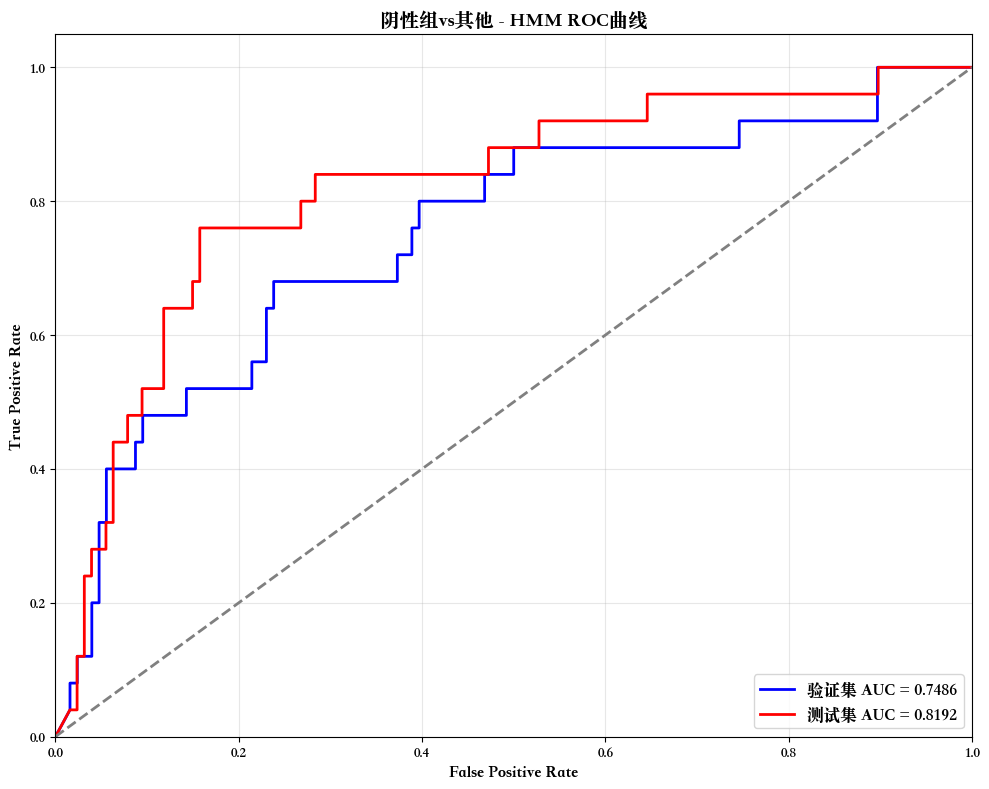

[I 2025-09-29 15:04:50,512] A new study created in memory with name: no-name-349c6355-be21-4e60-95ff-3f95aa822bf0
Model is not converging.  Current: -1906.081862167417 is not greater than -1876.5476043446845. Delta is -29.53425782273257
[I 2025-09-29 15:04:50,553] Trial 0 finished with value: 0.11015873015873012 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.11015873015873012.
[I 2025-09-29 15:04:50,577] Trial 1 finished with value: 0.2238095238095238 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.11015873015873012.
[I 2025-09-29 15:04:50,629] Trial 2 finished with value: 0.31206349206349215 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 0 with value: 0.11015873015873012.
[I 2025-09-29 15:04:50,678] Trial 3 finished with value: 0.38714285714285723 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_it

Index(['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量', '血_嗜酸性粒细胞百分比_定量', '血_葡萄糖空腹_定量',
       '血_结核感染T细胞检测_定性', '血_乙型肝炎病毒核心抗体.IgM_定量'],
      dtype='object')
开始超参数优化...


Model is not converging.  Current: -1413.6734724854255 is not greater than -1362.2781221231824. Delta is -51.39535036224311
[I 2025-09-29 15:04:50,730] Trial 4 finished with value: 0.16190476190476188 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 0 with value: 0.11015873015873012.
[I 2025-09-29 15:04:50,771] Trial 5 finished with value: 0.30666666666666664 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 0 with value: 0.11015873015873012.
[I 2025-09-29 15:04:50,810] Trial 6 finished with value: 0.03698412698412701 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.03698412698412701.
[I 2025-09-29 15:04:50,828] Trial 7 finished with value: 0.2238095238095238 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.03698412698412701.
[I 2025-09-29 15:04:50,866] Trial 8 finished with val


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9630
  Best params: 
    n_components: 4
    covariance_type: tied
    n_iter: 124

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.0596
Precision: 0.0084
Recall: 0.0400
F1-Score: 0.0139
AUC: 0.0370

测试 集评估结果:
Accuracy: 0.0066
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.0000

训练 集评估结果:
Accuracy: 0.0155
Precision: 0.0105
Recall: 0.0541
F1-Score: 0.0176
AUC: 0.0552


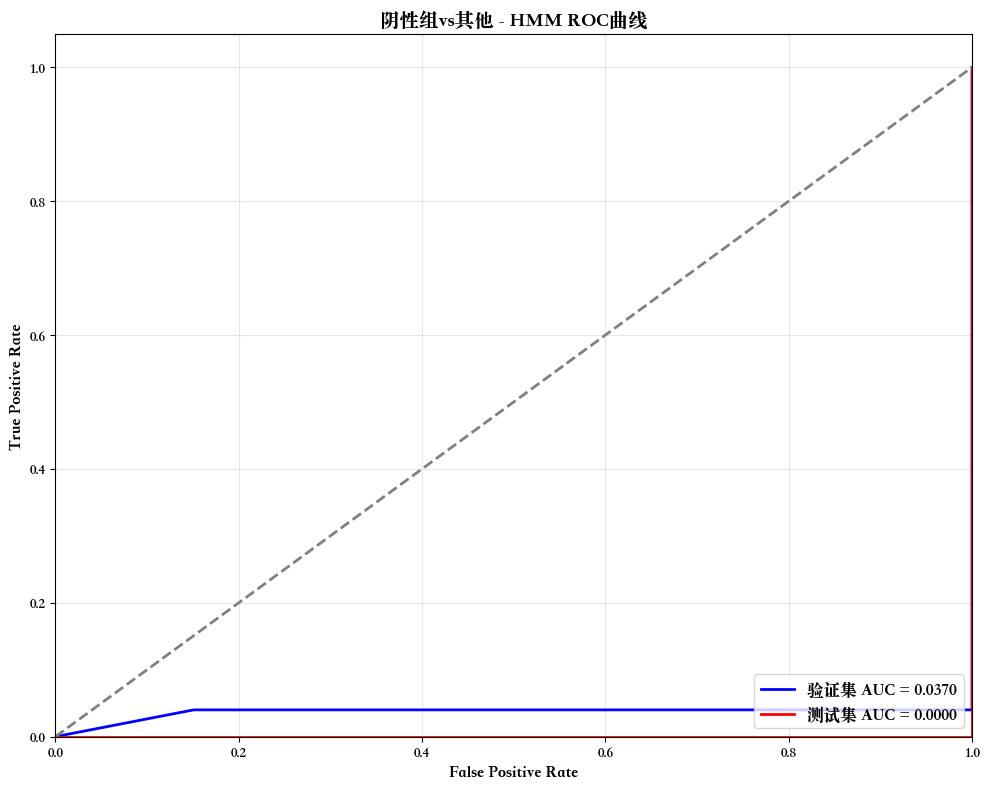

[I 2025-09-29 15:04:53,112] A new study created in memory with name: no-name-b5b7178b-0245-4c97-80f1-9cc165533cd4
[I 2025-09-29 15:04:53,173] Trial 0 finished with value: 0.3020989505247377 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.3020989505247377.
[I 2025-09-29 15:04:53,208] Trial 1 finished with value: 0.33083458270864574 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.3020989505247377.
[I 2025-09-29 15:04:53,289] Trial 2 finished with value: 0.25062468765617196 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.25062468765617196.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:04:53,329] Trial 3 finished with value: 0.4642678660669666 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.25062468765617196.
[I 2025-09-29 15:04:53,414] Trial 4 finished with value: 0.25262368815592207 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 2 with value: 0.25062468765617196.
[I 2025-09-29 15:04:53,453] Trial 5 finished with value: 0.23600699650174906 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 5 with value: 0.23600699650174906.
[I 2025-09-29 15:04:53,517] Trial 6 finished with value: 0.46026986506746626 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 5 with value: 0.23600699650174906.
[I 2025-09-29 15:04:53,552] Trial 7 finished with value: 0.33083458270864574 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 5 with 


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.8986
  Best params: 
    n_components: 10
    covariance_type: tied
    n_iter: 178

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.4488
Precision: 0.4957
Recall: 0.8261
F1-Score: 0.6196
AUC: 0.1487

测试 集评估结果:
Accuracy: 0.4724
Precision: 0.5091
Recall: 0.8116
F1-Score: 0.6257
AUC: 0.3177

训练 集评估结果:
Accuracy: 0.4603
Precision: 0.5031
Recall: 0.7961
F1-Score: 0.6165
AUC: 0.2796


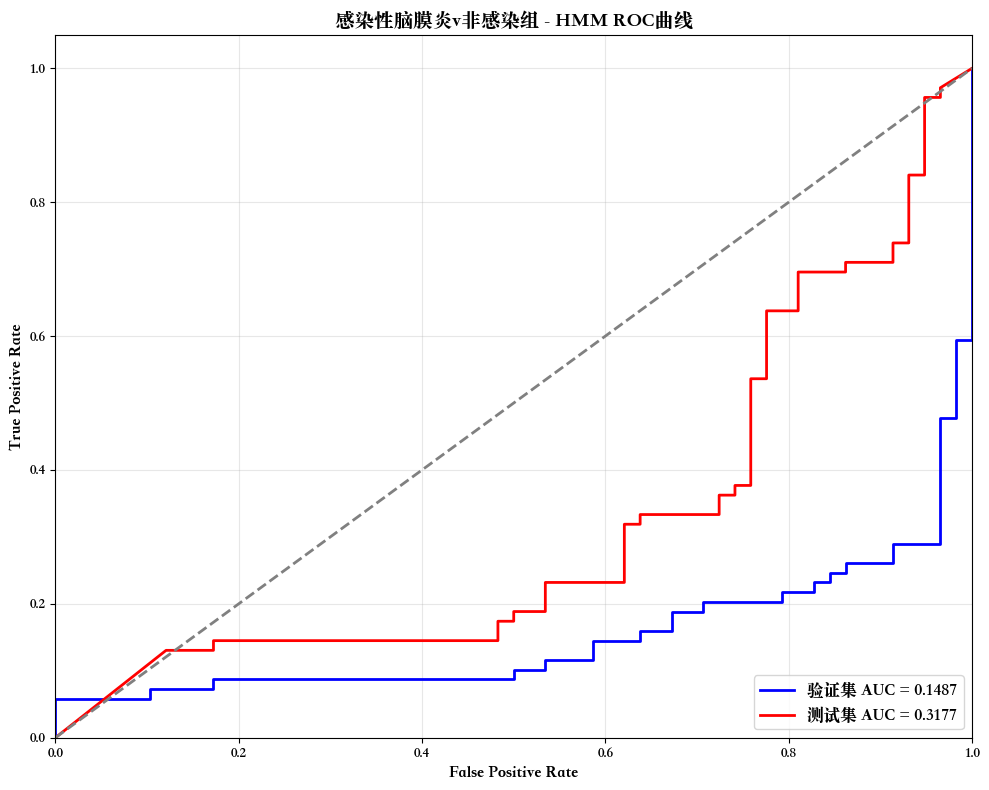

[I 2025-09-29 15:04:57,367] A new study created in memory with name: no-name-51cadd21-c447-40eb-98e1-3a3e5e76adc5
Model is not converging.  Current: 1334.2503641003418 is not greater than 1870.5638509738926. Delta is -536.3134868735508
[I 2025-09-29 15:04:57,411] Trial 0 finished with value: 0.22376311844077967 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.22376311844077967.
[I 2025-09-29 15:04:57,425] Trial 1 finished with value: 0.2896051974012993 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.22376311844077967.
[I 2025-09-29 15:04:57,470] Trial 2 finished with value: 0.16516741629185394 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.16516741629185394.
[I 2025-09-29 15:04:57,522] Trial 3 finished with value: 0.4355322338830585 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter

Index(['脑脊液_单个核细胞百分比_定量', '脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量', '脑脊液_多个核细胞百分比_定量'], dtype='object')
开始超参数优化...


[I 2025-09-29 15:04:57,584] Trial 5 finished with value: 0.27436281859070455 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.16516741629185394.
[I 2025-09-29 15:04:57,608] Trial 6 finished with value: 0.0 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.0.
[I 2025-09-29 15:04:57,624] Trial 7 finished with value: 0.2896051974012993 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.0.
[I 2025-09-29 15:04:57,689] Trial 8 finished with value: 0.22838580709645173 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 6 with value: 0.0.
Model is not converging.  Current: 241.15042349724297 is not greater than 331.38226539178527. Delta is -90.2318418945423
[I 2025-09-29 15:04:57,726] Trial 9 finished with value: 0.31234382808595706 and parameters: {'n_components': 7, 'covar


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 1.0000
  Best params: 
    n_components: 4
    covariance_type: tied
    n_iter: 124

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.9449
Precision: 1.0000
Recall: 0.8986
F1-Score: 0.9466
AUC: 0.9565

测试 集评估结果:
Accuracy: 0.9370
Precision: 0.9692
Recall: 0.9130
F1-Score: 0.9403
AUC: 0.9253

训练 集评估结果:
Accuracy: 0.9497
Precision: 0.9947
Recall: 0.9126
F1-Score: 0.9519
AUC: 0.9451


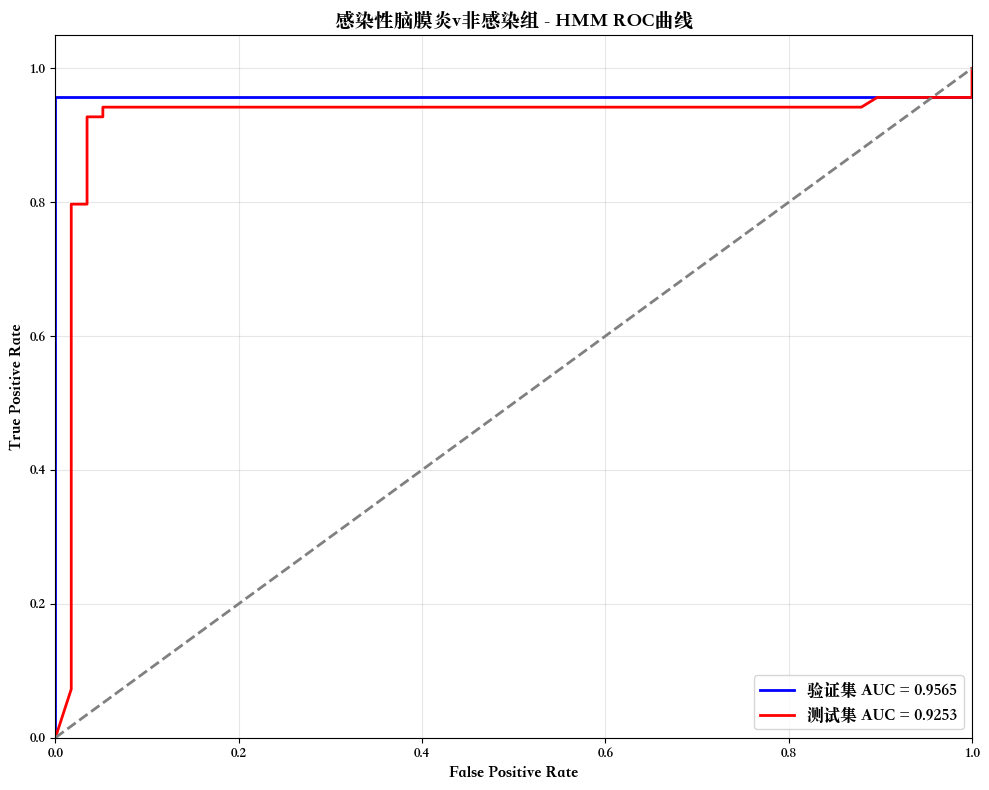

[I 2025-09-29 15:04:59,686] A new study created in memory with name: no-name-0ef4268f-9961-43cc-b218-a1feb935364a
Model is not converging.  Current: -4071.1419210193126 is not greater than -4057.607219046639. Delta is -13.534701972673702
[I 2025-09-29 15:04:59,708] Trial 0 finished with value: 0.5027472527472527 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.5027472527472527.
[I 2025-09-29 15:04:59,731] Trial 1 finished with value: 0.29807692307692313 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.29807692307692313.
[I 2025-09-29 15:04:59,759] Trial 2 finished with value: 0.42170329670329665 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 1 with value: 0.29807692307692313.
[I 2025-09-29 15:04:59,810] Trial 3 finished with value: 0.44780219780219777 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_it

Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:04:59,897] Trial 5 finished with value: 0.3585164835164836 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 1 with value: 0.29807692307692313.
[I 2025-09-29 15:04:59,933] Trial 6 finished with value: 0.29258241758241754 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.29258241758241754.
[I 2025-09-29 15:04:59,959] Trial 7 finished with value: 0.29807692307692313 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.29258241758241754.
[I 2025-09-29 15:04:59,995] Trial 8 finished with value: 0.2053571428571429 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 8 with value: 0.2053571428571429.
[I 2025-09-29 15:05:00,055] Trial 9 finished with value: 0.16758241758241754 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 9 with va


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9087
  Best params: 
    n_components: 7
    covariance_type: tied
    n_iter: 192

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.7971
Precision: 0.4286
Recall: 0.2308
F1-Score: 0.3000
AUC: 0.6690

测试 集评估结果:
Accuracy: 0.8116
Precision: 0.5000
Recall: 0.3077
F1-Score: 0.3810
AUC: 0.4663

训练 集评估结果:
Accuracy: 0.7524
Precision: 0.3143
Recall: 0.2895
F1-Score: 0.3014
AUC: 0.4317


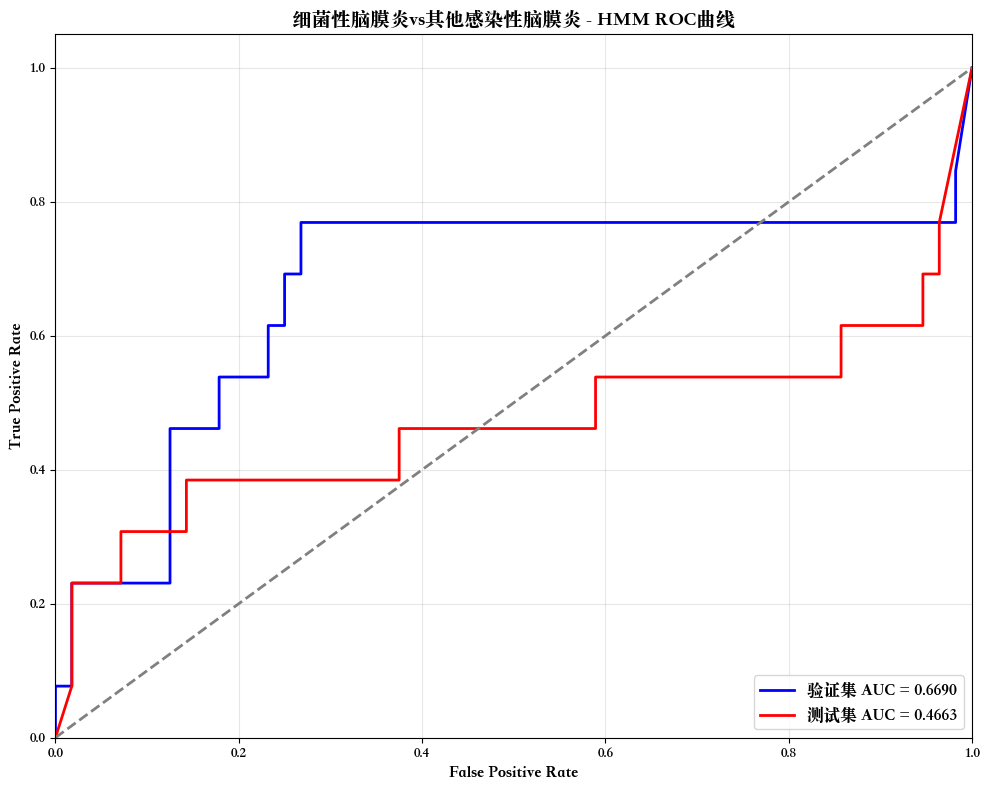

[I 2025-09-29 15:05:02,612] A new study created in memory with name: no-name-bd361e4b-429b-47ac-9dc7-336f2558c991
Model is not converging.  Current: -1253.716410804579 is not greater than -1158.977724330035. Delta is -94.73868647454401
[I 2025-09-29 15:05:02,631] Trial 0 finished with value: 0.35027472527472525 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.35027472527472525.
[I 2025-09-29 15:05:02,659] Trial 1 finished with value: 0.25137362637362637 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.25137362637362637.
[I 2025-09-29 15:05:02,681] Trial 2 finished with value: 0.31593406593406603 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 1 with value: 0.25137362637362637.
[I 2025-09-29 15:05:02,707] Trial 3 finished with value: 0.3749999999999999 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_ite

Index(['脑脊液_多个核细胞百分比_定量', '血_C反应蛋白_定量', '脑脊液_有核细胞计数_定量', '血_抗凝血酶III_定量',
       '血_血小板分布宽度_定量', '血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量'],
      dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:02,833] Trial 8 finished with value: 0.3392857142857143 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 5 with value: 0.2362637362637362.
[I 2025-09-29 15:05:02,868] Trial 9 finished with value: 0.25274725274725274 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 5 with value: 0.2362637362637362.
[I 2025-09-29 15:05:02,912] Trial 10 finished with value: 0.3612637362637362 and parameters: {'n_components': 10, 'covariance_type': 'spherical', 'n_iter': 170}. Best is trial 5 with value: 0.2362637362637362.
[I 2025-09-29 15:05:02,950] Trial 11 finished with value: 0.25274725274725274 and parameters: {'n_components': 8, 'covariance_type': 'diag', 'n_iter': 55}. Best is trial 5 with value: 0.2362637362637362.
[I 2025-09-29 15:05:02,973] Trial 12 finished with value: 0.2362637362637362 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 162}. Best is trial 5 wit


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.7775
  Best params: 
    n_components: 4
    covariance_type: diag
    n_iter: 178

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.5652
Precision: 0.2821
Recall: 0.8462
F1-Score: 0.4231
AUC: 0.7665

测试 集评估结果:
Accuracy: 0.6377
Precision: 0.3333
Recall: 0.9231
F1-Score: 0.4898
AUC: 0.8331

训练 集评估结果:
Accuracy: 0.5097
Precision: 0.2558
Recall: 0.8684
F1-Score: 0.3952
AUC: 0.7852


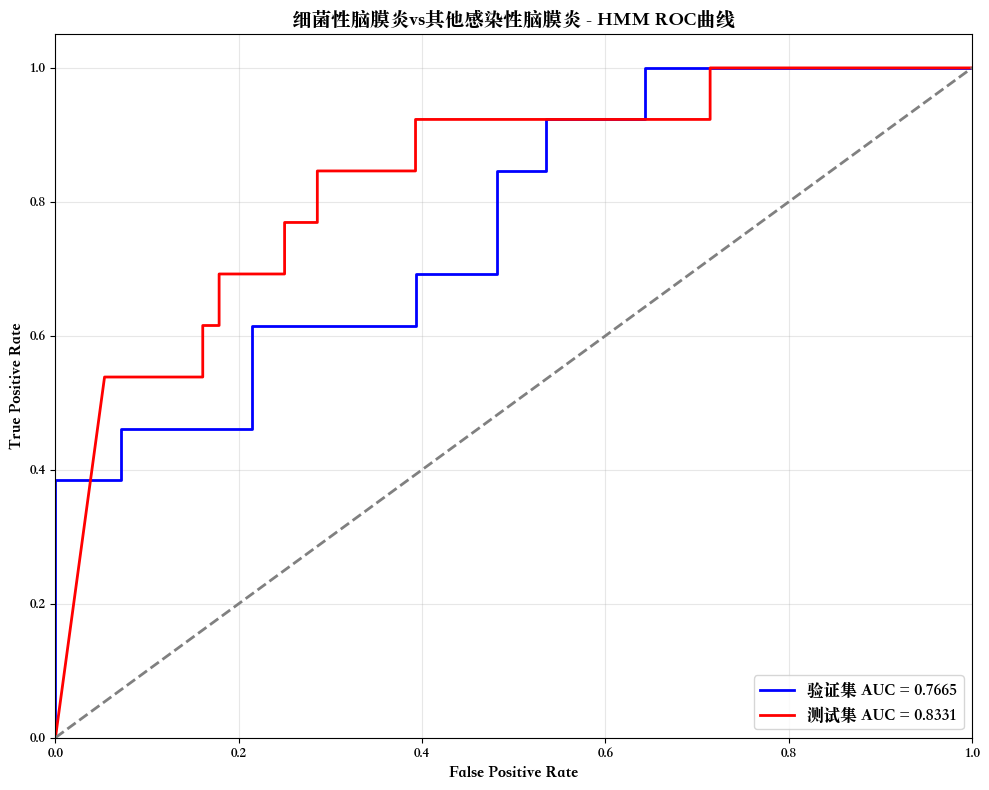

[I 2025-09-29 15:05:03,973] A new study created in memory with name: no-name-81ae8d26-b0b9-4bfc-a51f-d0cbe15d785c
[I 2025-09-29 15:05:04,012] Trial 0 finished with value: 0.49037487335359675 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.49037487335359675.
[I 2025-09-29 15:05:04,063] Trial 1 finished with value: 0.46808510638297873 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.46808510638297873.
[I 2025-09-29 15:05:04,141] Trial 2 finished with value: 0.44680851063829785 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.44680851063829785.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:05:04,214] Trial 3 finished with value: 0.4670719351570416 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.44680851063829785.
Model is not converging.  Current: -3685.7786041149216 is not greater than -3527.1973510176554. Delta is -158.5812530972662
[I 2025-09-29 15:05:04,243] Trial 4 finished with value: 0.5764944275582573 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 2 with value: 0.44680851063829785.
[I 2025-09-29 15:05:04,291] Trial 5 finished with value: 0.44680851063829785 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.44680851063829785.
[I 2025-09-29 15:05:04,323] Trial 6 finished with value: 0.023302938196555267 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.023302938196555267.
[I 2025-09-29 15:05:04,347] Trial 7 finished with va


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9767
  Best params: 
    n_components: 4
    covariance_type: tied
    n_iter: 124

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.7647
Precision: 1.0000
Recall: 0.2381
F1-Score: 0.3846
AUC: 0.9767

测试 集评估结果:
Accuracy: 0.8857
Precision: 0.7692
Recall: 0.9091
F1-Score: 0.8333
AUC: 0.9408

训练 集评估结果:
Accuracy: 0.8883
Precision: 0.9767
Recall: 0.6562
F1-Score: 0.7850
AUC: 0.9107


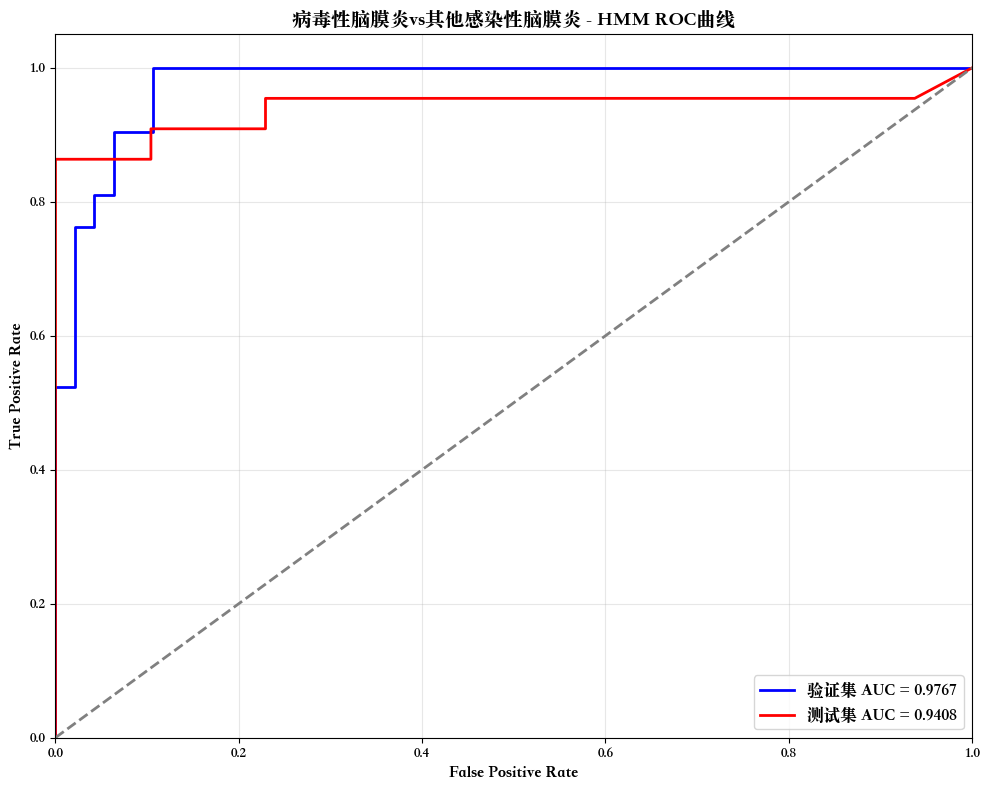

[I 2025-09-29 15:05:06,616] A new study created in memory with name: no-name-cf81d1ac-5535-4a1d-8443-0b16b981a9dc
[I 2025-09-29 15:05:06,664] Trial 0 finished with value: 0.25683890577507595 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.25683890577507595.
[I 2025-09-29 15:05:06,676] Trial 1 finished with value: 0.3383991894630193 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.25683890577507595.
[I 2025-09-29 15:05:06,705] Trial 2 finished with value: 0.358662613981763 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 0 with value: 0.25683890577507595.
[I 2025-09-29 15:05:06,730] Trial 3 finished with value: 0.2978723404255319 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 0 with value: 0.25683890577507595.
Model is not converging.  Current: -807.7777603004689 is not great

Index(['脑脊液_葡萄糖_定量', '脑脊液_中性粒细胞百分比_定量', '血_肌酸激酶_定量', '血_肾小球滤过率_定量',
       '血_免疫球蛋白E_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '脑脊液_多个核细胞百分比_定量',
       '脑脊液_蛋白定量_定量'],
      dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:06,826] Trial 7 finished with value: 0.3383991894630193 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 0 with value: 0.25683890577507595.
[I 2025-09-29 15:05:06,866] Trial 8 finished with value: 0.0 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 8 with value: 0.0.
Model is not converging.  Current: -644.7090928258407 is not greater than -644.5332507662451. Delta is -0.17584205959553856
[I 2025-09-29 15:05:06,919] Trial 9 finished with value: 0.2872340425531915 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 8 with value: 0.0.
[I 2025-09-29 15:05:06,944] Trial 10 finished with value: 0.30597771023302944 and parameters: {'n_components': 10, 'covariance_type': 'diag', 'n_iter': 170}. Best is trial 8 with value: 0.0.
[I 2025-09-29 15:05:06,965] Trial 11 finished with value: 0.5 and parameters: {'n_components': 4, 'covariance_type': 'tie


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 1.0000
  Best params: 
    n_components: 6
    covariance_type: tied
    n_iter: 185

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.5441
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.4600

测试 集评估结果:
Accuracy: 0.5429
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.4839

训练 集评估结果:
Accuracy: 0.5485
Precision: 0.0857
Recall: 0.0469
F1-Score: 0.0606
AUC: 0.4928


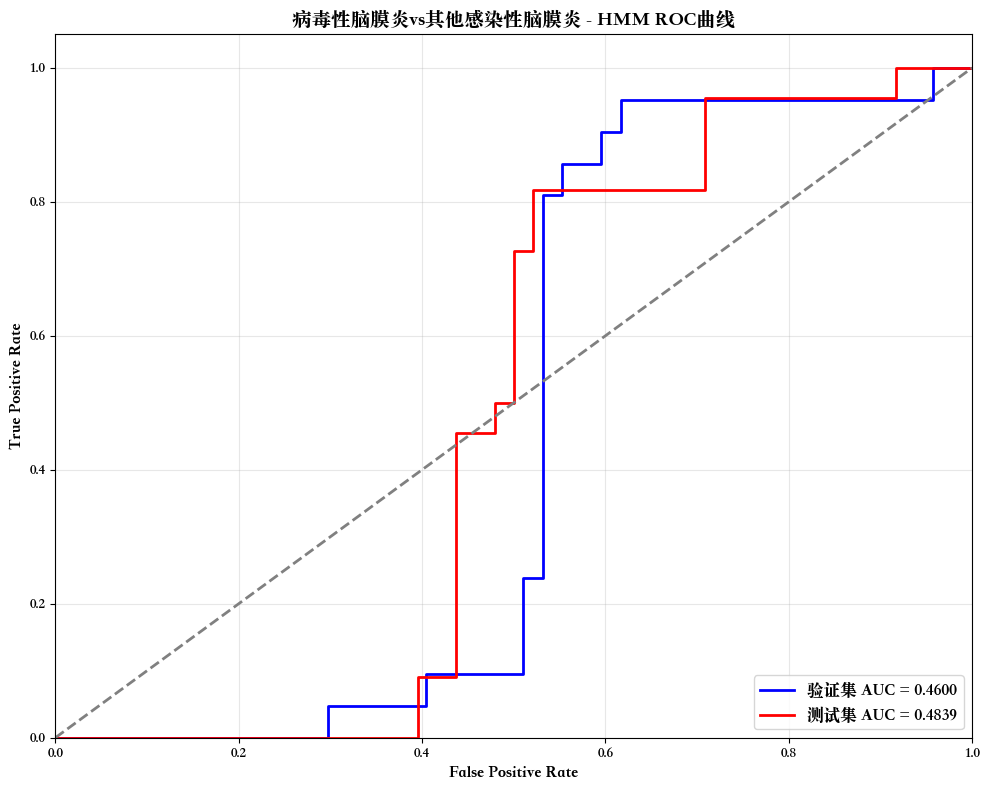

[I 2025-09-29 15:05:08,432] A new study created in memory with name: no-name-bd59d4d8-9d78-4383-9e5c-06c7f6defac8
[I 2025-09-29 15:05:08,466] Trial 0 finished with value: 0.5416666666666667 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.5416666666666667.
[I 2025-09-29 15:05:08,482] Trial 1 finished with value: 0.6473214285714286 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.5416666666666667.
[I 2025-09-29 15:05:08,509] Trial 2 finished with value: 0.3623511904761906 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,583] Trial 3 finished with value: 0.49404761904761907 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,608] Trial 4 finished with value: 0.5974702380

Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:05:08,638] Trial 5 finished with value: 0.37574404761904767 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,664] Trial 6 finished with value: 0.5208333333333334 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,683] Trial 7 finished with value: 0.6473214285714286 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,724] Trial 8 finished with value: 0.59375 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 2 with value: 0.3623511904761906.
[I 2025-09-29 15:05:08,762] Trial 9 finished with value: 0.45163690476190477 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 2 with value: 0.36235119


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.7128
  Best params: 
    n_components: 9
    covariance_type: tied
    n_iter: 177

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.6324
Precision: 0.2903
Recall: 0.7500
F1-Score: 0.4186
AUC: 0.7470

测试 集评估结果:
Accuracy: 0.4857
Precision: 0.2326
Recall: 0.7692
F1-Score: 0.3571
AUC: 0.6100

训练 集评估结果:
Accuracy: 0.4466
Precision: 0.2016
Recall: 0.7027
F1-Score: 0.3133
AUC: 0.5586


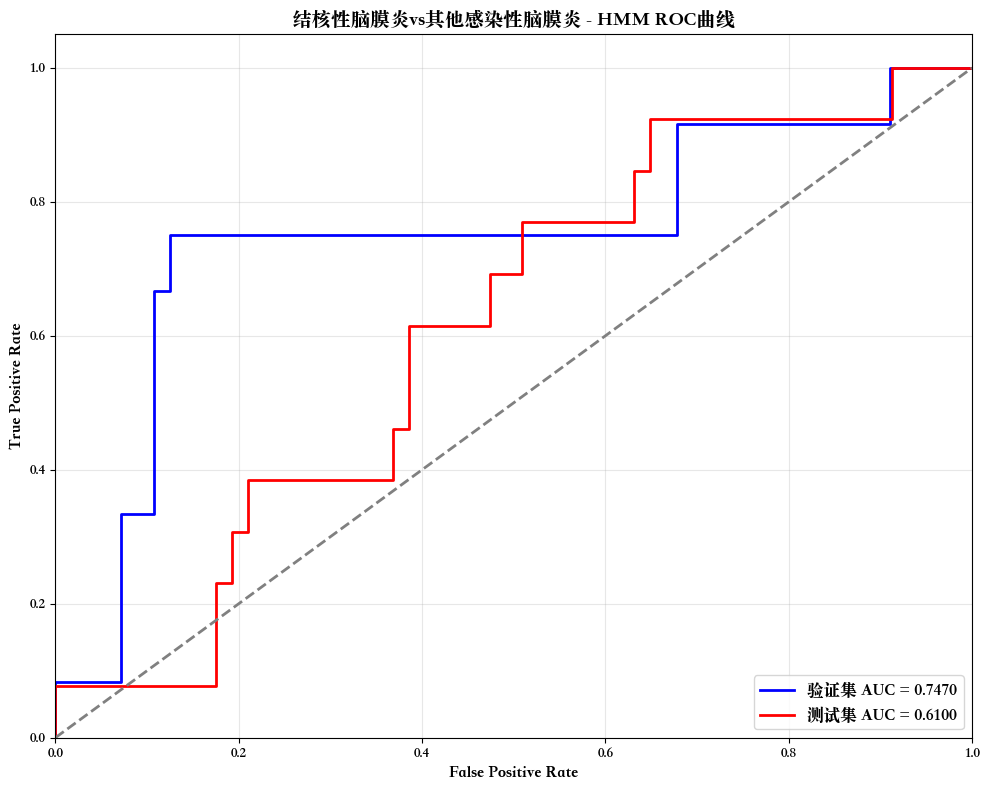

[I 2025-09-29 15:05:10,947] A new study created in memory with name: no-name-d7e9f711-761c-424f-8146-207cfe27b7f1
[I 2025-09-29 15:05:10,975] Trial 0 finished with value: 0.1785714285714286 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.1785714285714286.
Model is not converging.  Current: -1366.812014587333 is not greater than -1366.8023345519746. Delta is -0.009680035358314854
[I 2025-09-29 15:05:10,991] Trial 1 finished with value: 0.2142857142857143 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.1785714285714286.
[I 2025-09-29 15:05:11,020] Trial 2 finished with value: 0.12797619047619058 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.12797619047619058.
[I 2025-09-29 15:05:11,085] Trial 3 finished with value: 0.40625 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. B

Index(['血_结核感染T细胞检测_定性', '脑脊液_氯_定量', '血_结核感染T细胞测试管_定量', '脑脊液_葡萄糖_定量',
       '血_淋巴细胞计数_定量', '血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量'],
      dtype='object')
开始超参数优化...


Model is not converging.  Current: -1366.812014587333 is not greater than -1366.8023345519746. Delta is -0.009680035358314854
[I 2025-09-29 15:05:11,157] Trial 7 finished with value: 0.2142857142857143 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 2 with value: 0.12797619047619058.
[I 2025-09-29 15:05:11,188] Trial 8 finished with value: 0.2924107142857143 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 2 with value: 0.12797619047619058.
Model is not converging.  Current: -586.1993588913281 is not greater than -560.1862303911075. Delta is -26.013128500220546
[I 2025-09-29 15:05:11,212] Trial 9 finished with value: 0.22619047619047628 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 2 with value: 0.12797619047619058.
[I 2025-09-29 15:05:11,258] Trial 10 finished with value: 0.14136904761904756 and parameters: {'n_components': 10, 'covariance_type': 'sphe


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9717
  Best params: 
    n_components: 7
    covariance_type: diag
    n_iter: 115

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.7794
Precision: 0.3846
Recall: 0.4167
F1-Score: 0.4000
AUC: 0.7277

测试 集评估结果:
Accuracy: 0.7429
Precision: 0.3333
Recall: 0.3846
F1-Score: 0.3571
AUC: 0.6680

训练 集评估结果:
Accuracy: 0.7524
Precision: 0.3333
Recall: 0.3784
F1-Score: 0.3544
AUC: 0.6268


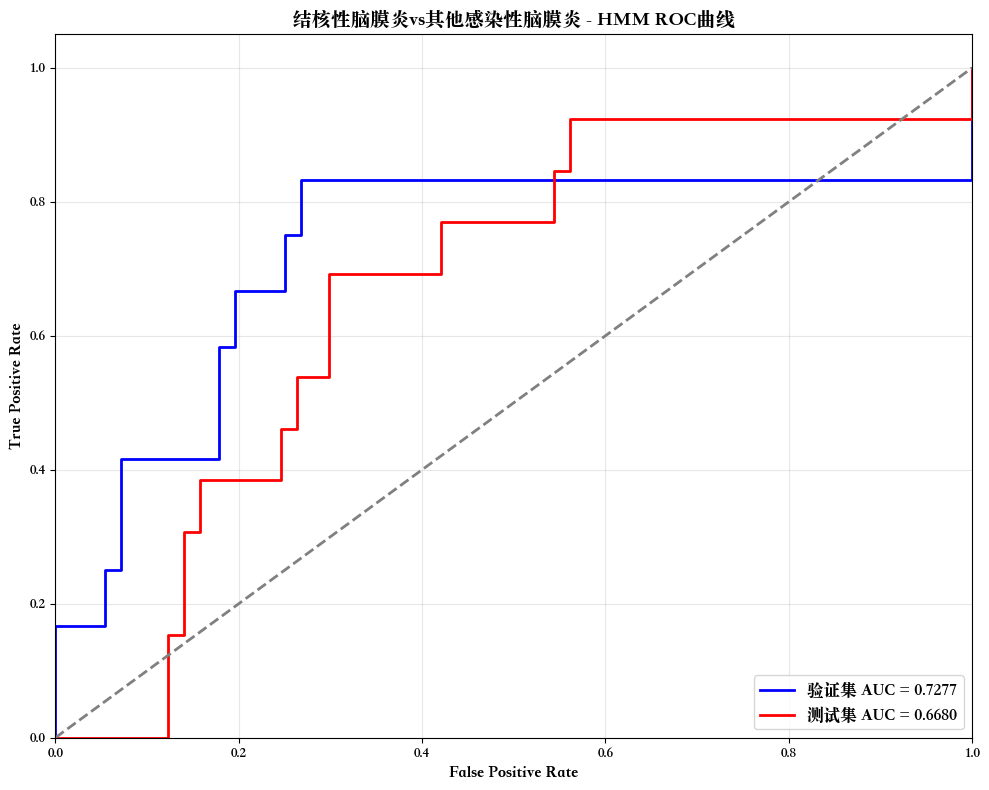

[I 2025-09-29 15:05:13,185] A new study created in memory with name: no-name-211adbc4-28d4-44de-b091-ecf99b625da1
[I 2025-09-29 15:05:13,236] Trial 0 finished with value: 0.5232108317214701 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.5232108317214701.
[I 2025-09-29 15:05:13,266] Trial 1 finished with value: 0.3786266924564796 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.3786266924564796.
[I 2025-09-29 15:05:13,298] Trial 2 finished with value: 0.26595744680851063 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.26595744680851063.
[I 2025-09-29 15:05:13,362] Trial 3 finished with value: 0.3563829787234043 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.26595744680851063.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:05:13,399] Trial 4 finished with value: 0.4956479690522244 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 2 with value: 0.26595744680851063.
[I 2025-09-29 15:05:13,460] Trial 5 finished with value: 0.3810444874274661 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.26595744680851063.
[I 2025-09-29 15:05:13,495] Trial 6 finished with value: 0.4269825918762089 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 2 with value: 0.26595744680851063.
[I 2025-09-29 15:05:13,529] Trial 7 finished with value: 0.3786266924564796 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 2 with value: 0.26595744680851063.
[I 2025-09-29 15:05:13,608] Trial 8 finished with value: 0.4995164410058027 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 2 with valu


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.8433
  Best params: 
    n_components: 6
    covariance_type: spherical
    n_iter: 115

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.7391
Precision: 0.6667
Recall: 0.3636
F1-Score: 0.4706
AUC: 0.8230

测试 集评估结果:
Accuracy: 0.7571
Precision: 1.0000
Recall: 0.2609
F1-Score: 0.4138
AUC: 0.7558

训练 集评估结果:
Accuracy: 0.8049
Precision: 0.8421
Recall: 0.4848
F1-Score: 0.6154
AUC: 0.7850


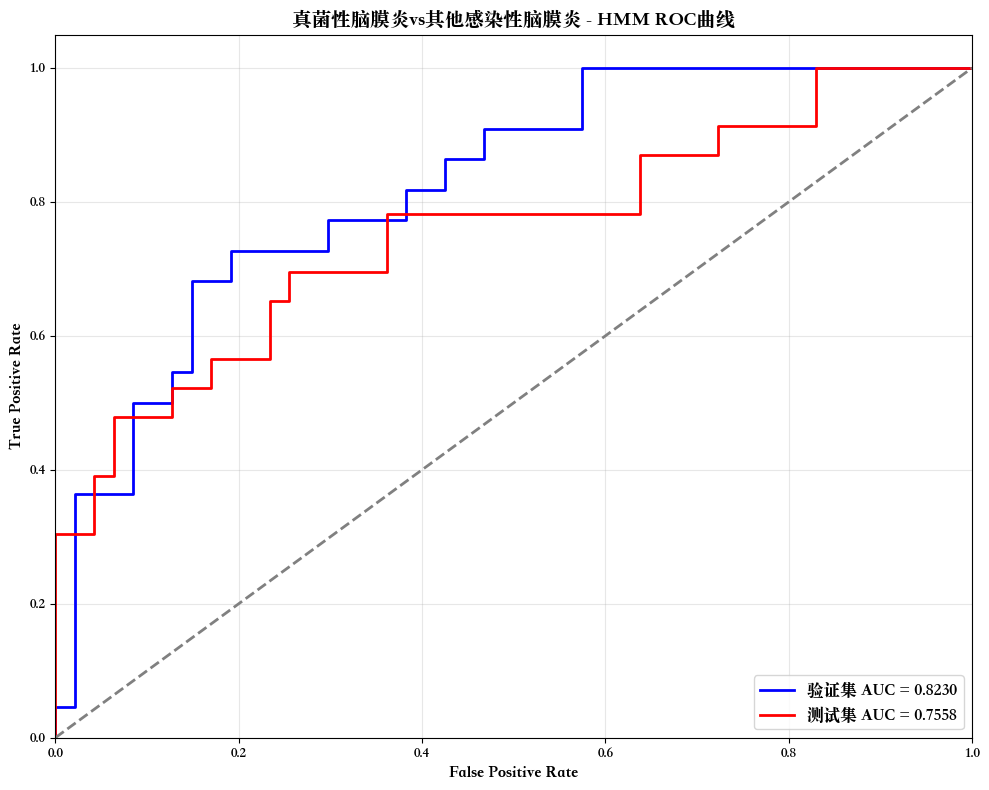

[I 2025-09-29 15:05:15,688] A new study created in memory with name: no-name-19b1640f-0624-442b-baa5-a04d28e388bb
[I 2025-09-29 15:05:15,760] Trial 0 finished with value: 0.2640232108317214 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.2640232108317214.
[I 2025-09-29 15:05:15,768] Trial 1 finished with value: 0.5 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.2640232108317214.
[I 2025-09-29 15:05:15,811] Trial 2 finished with value: 0.40328820116054165 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 0 with value: 0.2640232108317214.
[I 2025-09-29 15:05:15,855] Trial 3 finished with value: 0.18665377176015474 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 3 with value: 0.18665377176015474.


Index(['血_细胞.CD3-CD19+百分比_定量', '血_不规则抗体_定性', '脑脊液_有核细胞计数_定量'], dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:15,891] Trial 4 finished with value: 0.379110251450677 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 3 with value: 0.18665377176015474.
[I 2025-09-29 15:05:15,938] Trial 5 finished with value: 0.23791102514506768 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 3 with value: 0.18665377176015474.
[I 2025-09-29 15:05:15,956] Trial 6 finished with value: 0.0067698259187620735 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.0067698259187620735.
[I 2025-09-29 15:05:15,966] Trial 7 finished with value: 0.5 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.0067698259187620735.
[I 2025-09-29 15:05:16,005] Trial 8 finished with value: 0.42166344294003877 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 6 with value: 0.00


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9932
  Best params: 
    n_components: 4
    covariance_type: tied
    n_iter: 124

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.7681
Precision: 0.5789
Recall: 1.0000
F1-Score: 0.7333
AUC: 0.9105

测试 集评估结果:
Accuracy: 0.8714
Precision: 0.7188
Recall: 1.0000
F1-Score: 0.8364
AUC: 0.9191

训练 集评估结果:
Accuracy: 0.8439
Precision: 0.7125
Recall: 0.8636
F1-Score: 0.7808
AUC: 0.9045


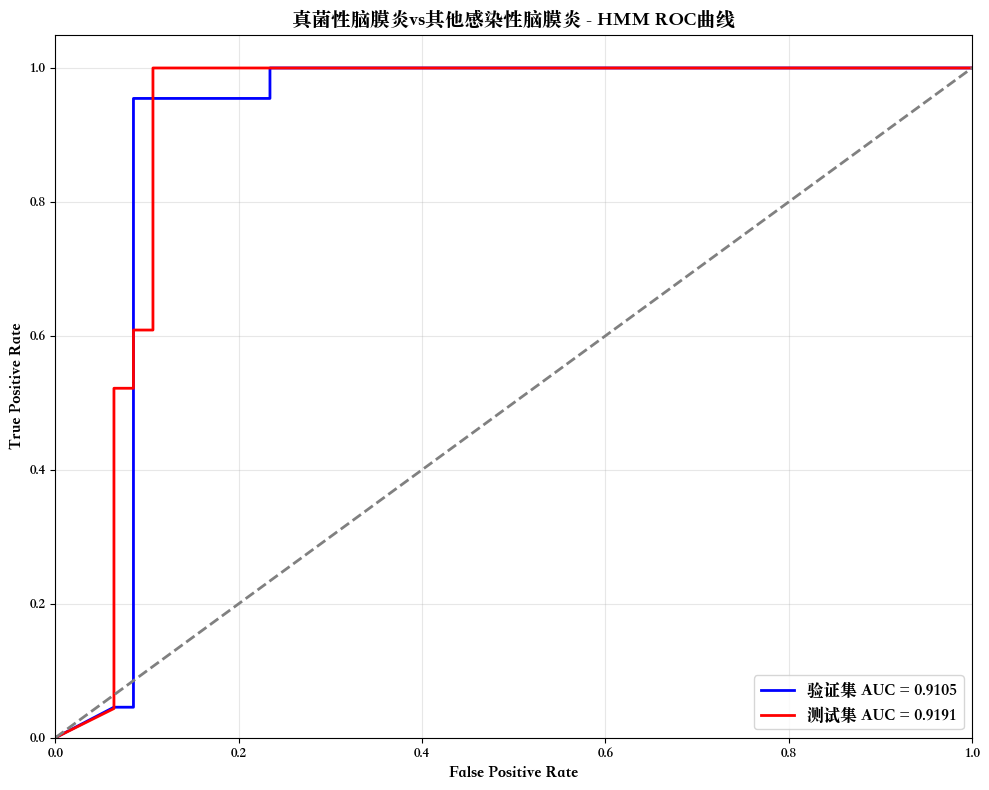

[I 2025-09-29 15:05:17,482] A new study created in memory with name: no-name-e0c8ae67-caa0-4a18-80c0-d9db02783ac1


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=218)
开始超参数优化...


Model is not converging.  Current: -8320.801848780733 is not greater than -8246.906500742944. Delta is -73.89534803778952
[I 2025-09-29 15:05:17,709] Trial 0 finished with value: 0.4901639344262294 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.4901639344262294.
[I 2025-09-29 15:05:17,755] Trial 1 finished with value: 0.28060109289617485 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.28060109289617485.
[I 2025-09-29 15:05:17,803] Trial 2 finished with value: 0.13005464480874318 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.13005464480874318.
[I 2025-09-29 15:05:17,857] Trial 3 finished with value: 0.3366120218579236 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.13005464480874318.
[I 2025-09-29 15:05:17,931] Trial 4 finished with value: 


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 1.0000
  Best params: 
    n_components: 9
    covariance_type: tied
    n_iter: 173

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.3224
Precision: 0.2256
Recall: 1.0000
F1-Score: 0.3681
AUC: 0.8410

测试 集评估结果:
Accuracy: 0.2697
Precision: 0.2086
Recall: 0.9667
F1-Score: 0.3432
AUC: 0.6601

训练 集评估结果:
Accuracy: 0.3053
Precision: 0.2161
Recall: 0.9773
F1-Score: 0.3539
AUC: 0.7690


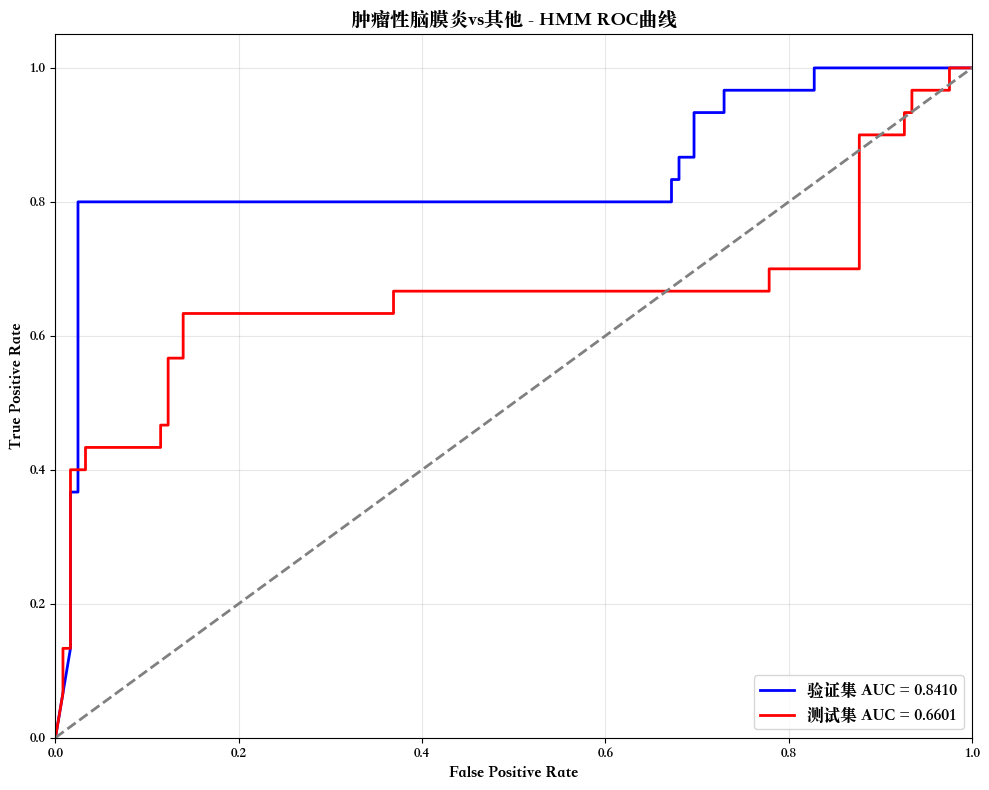

[I 2025-09-29 15:05:23,411] A new study created in memory with name: no-name-7c9486d0-3cfe-4c45-b752-3824b11b1ef9
[I 2025-09-29 15:05:23,507] Trial 0 finished with value: 0.32240437158469937 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.32240437158469937.
[I 2025-09-29 15:05:23,528] Trial 1 finished with value: 0.4841530054644808 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.32240437158469937.


Index(['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量',
       'age'],
      dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:23,654] Trial 2 finished with value: 0.2844262295081966 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.2844262295081966.
[I 2025-09-29 15:05:23,751] Trial 3 finished with value: 0.41530054644808745 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.2844262295081966.
[I 2025-09-29 15:05:23,846] Trial 4 finished with value: 0.2524590163934426 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 4 with value: 0.2524590163934426.
[I 2025-09-29 15:05:23,911] Trial 5 finished with value: 0.26475409836065567 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 4 with value: 0.2524590163934426.
[I 2025-09-29 15:05:23,935] Trial 6 finished with value: 0.06325136612021853 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with 


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.9367
  Best params: 
    n_components: 4
    covariance_type: tied
    n_iter: 124

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.9342
Precision: 0.9167
Recall: 0.7333
F1-Score: 0.8148
AUC: 0.9367

测试 集评估结果:
Accuracy: 0.8487
Precision: 0.6522
Recall: 0.5000
F1-Score: 0.5660
AUC: 0.8542

训练 集评估结果:
Accuracy: 0.9845
Precision: 0.9263
Recall: 1.0000
F1-Score: 0.9617
AUC: 0.9890


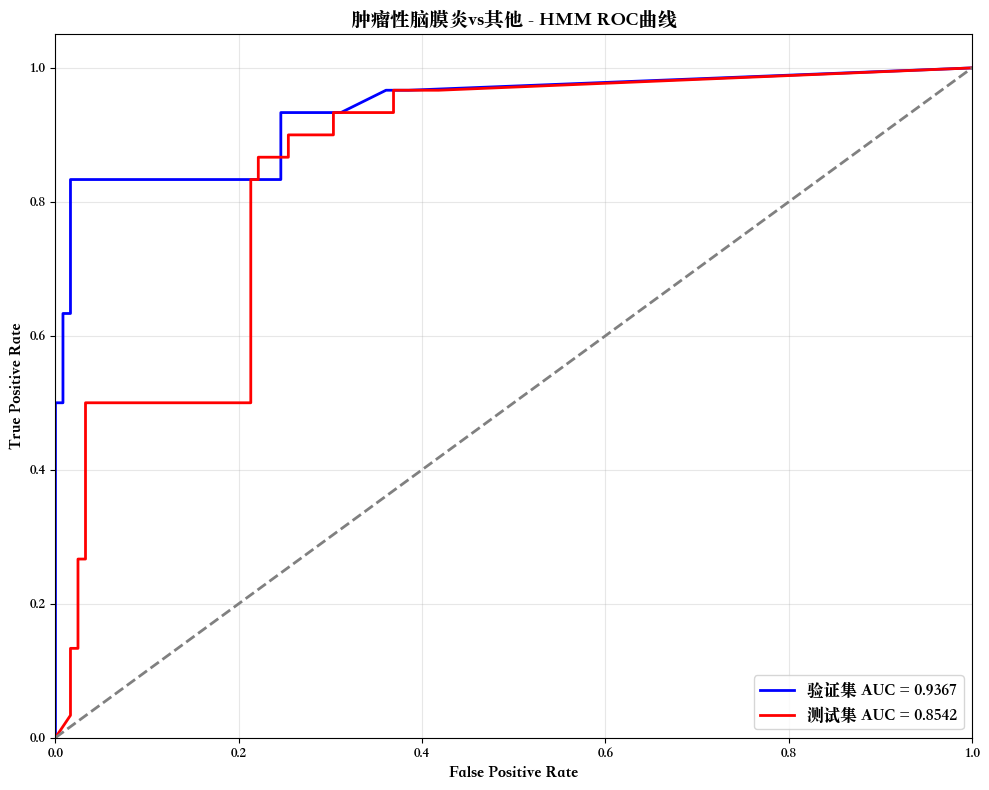

[I 2025-09-29 15:05:26,799] A new study created in memory with name: no-name-8629e6c5-b503-48dd-b882-c388be3e0434
[I 2025-09-29 15:05:26,880] Trial 0 finished with value: 0.37746806039488967 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.37746806039488967.
[I 2025-09-29 15:05:26,913] Trial 1 finished with value: 0.31068524970963984 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.31068524970963984.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=218)
开始超参数优化...


[I 2025-09-29 15:05:27,027] Trial 2 finished with value: 0.2700348432055748 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 2 with value: 0.2700348432055748.
[I 2025-09-29 15:05:27,136] Trial 3 finished with value: 0.44613821138211385 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 2 with value: 0.2700348432055748.
[I 2025-09-29 15:05:27,231] Trial 4 finished with value: 0.3546747967479674 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 2 with value: 0.2700348432055748.
[I 2025-09-29 15:05:27,290] Trial 5 finished with value: 0.3334785133565622 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 2 with value: 0.2700348432055748.
[I 2025-09-29 15:05:27,454] Trial 6 finished with value: 0.5 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 2 with value: 0.27003484


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.7300
  Best params: 
    n_components: 9
    covariance_type: spherical
    n_iter: 129

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.6623
Precision: 0.2051
Recall: 0.2857
F1-Score: 0.2388
AUC: 0.3929

测试 集评估结果:
Accuracy: 0.6447
Precision: 0.2045
Recall: 0.3214
F1-Score: 0.2500
AUC: 0.4628

训练 集评估结果:
Accuracy: 0.6380
Precision: 0.2183
Recall: 0.3690
F1-Score: 0.2743
AUC: 0.5251


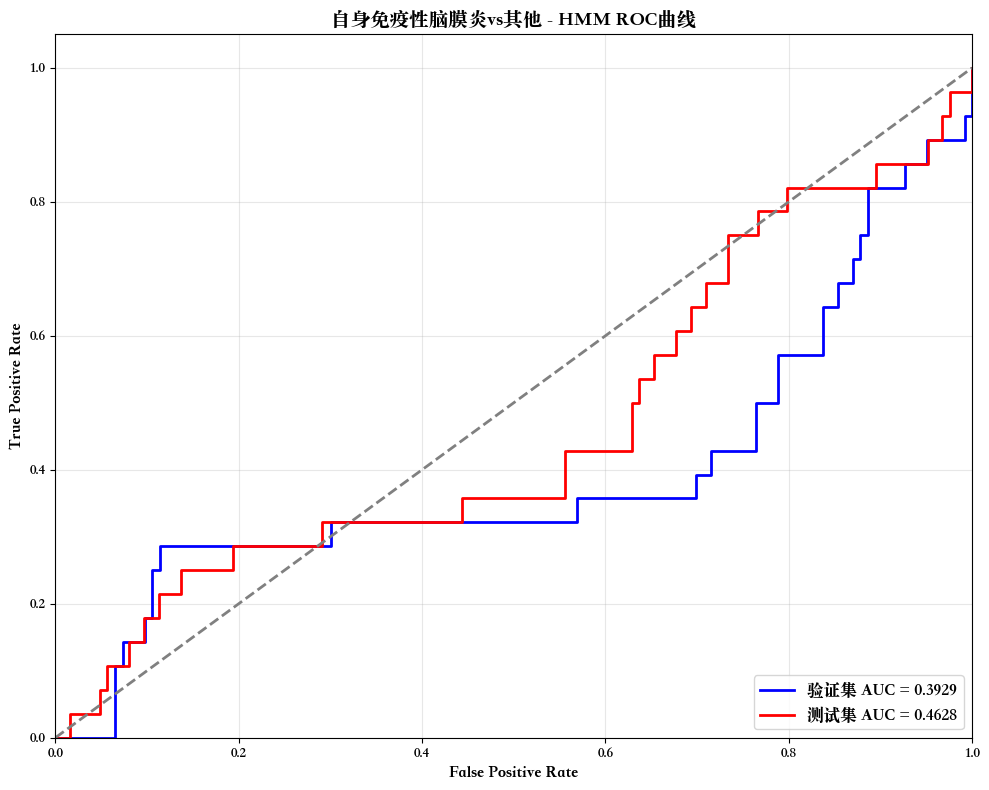

[I 2025-09-29 15:05:31,764] A new study created in memory with name: no-name-cb4c999a-fba8-4656-b9b6-8fea1483c73b
Model is not converging.  Current: -2676.4341647339734 is not greater than -2620.3757737078863. Delta is -56.058391026087065
[I 2025-09-29 15:05:31,796] Trial 0 finished with value: 0.25493612078977934 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.25493612078977934.
[I 2025-09-29 15:05:31,818] Trial 1 finished with value: 0.398664343786295 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.25493612078977934.
[I 2025-09-29 15:05:31,865] Trial 2 finished with value: 0.3745644599303136 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 0 with value: 0.25493612078977934.
[I 2025-09-29 15:05:31,940] Trial 3 finished with value: 0.5362950058072009 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_ite

Index(['血_丙型肝炎病毒抗体_定量', '脑脊液_葡萄糖_定量', '血_结核感染T细胞测试管_定量', '血_铁蛋白_定量',
       '脑脊液_蛋白定量_定量', '血_D-二聚体_定量', '血_乙型肝炎病毒核心抗体.IgM_定量', 'age'],
      dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:31,963] Trial 4 finished with value: 0.3866144018583043 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 0 with value: 0.25493612078977934.
[I 2025-09-29 15:05:32,052] Trial 5 finished with value: 0.2784552845528456 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 0 with value: 0.25493612078977934.
[I 2025-09-29 15:05:32,079] Trial 6 finished with value: 0.030197444831591147 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.030197444831591147.
[I 2025-09-29 15:05:32,108] Trial 7 finished with value: 0.398664343786295 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.030197444831591147.
[I 2025-09-29 15:05:32,171] Trial 8 finished with value: 0.1591173054587688 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 6 with v


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 1.0000
  Best params: 
    n_components: 8
    covariance_type: tied
    n_iter: 176

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.9470
Precision: 0.7778
Recall: 1.0000
F1-Score: 0.8750
AUC: 0.9611

测试 集评估结果:
Accuracy: 0.7895
Precision: 0.3000
Recall: 0.1071
F1-Score: 0.1579
AUC: 0.8086

训练 集评估结果:
Accuracy: 0.8918
Precision: 0.6357
Recall: 0.9762
F1-Score: 0.7700
AUC: 0.9388


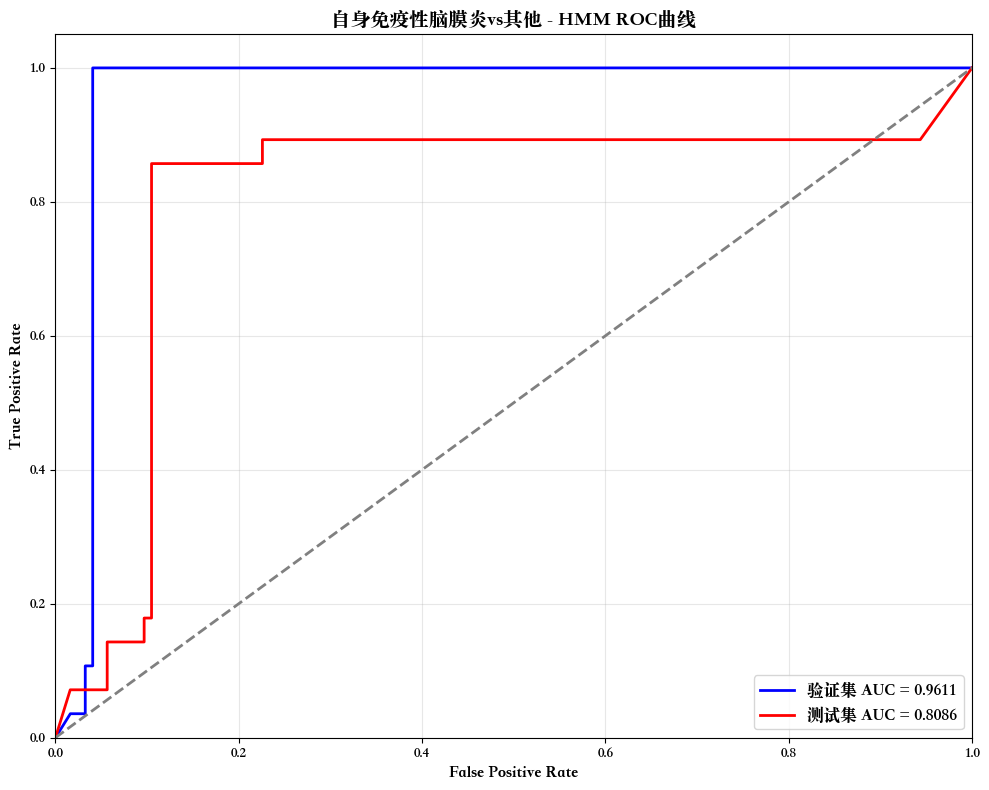

[I 2025-09-29 15:05:37,356] A new study created in memory with name: no-name-03dac52e-1bf7-4036-b089-5e885f1372d9
[I 2025-09-29 15:05:37,400] Trial 0 finished with value: 0.575091575091575 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.575091575091575.
[I 2025-09-29 15:05:37,434] Trial 1 finished with value: 0.4587912087912088 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 1 with value: 0.4587912087912088.
[I 2025-09-29 15:05:37,486] Trial 2 finished with value: 0.5421245421245422 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 1 with value: 0.4587912087912088.
[I 2025-09-29 15:05:37,533] Trial 3 finished with value: 0.4990842490842491 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 1 with value: 0.4587912087912088.


Index(['血_1,3-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量',
       '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量',
       '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)
开始超参数优化...


[I 2025-09-29 15:05:37,566] Trial 4 finished with value: 0.5192307692307692 and parameters: {'n_components': 6, 'covariance_type': 'full', 'n_iter': 57}. Best is trial 1 with value: 0.4587912087912088.
[I 2025-09-29 15:05:37,601] Trial 5 finished with value: 0.5402930402930403 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'n_iter': 172}. Best is trial 1 with value: 0.4587912087912088.
[I 2025-09-29 15:05:37,641] Trial 6 finished with value: 0.40293040293040294 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 6 with value: 0.40293040293040294.
[I 2025-09-29 15:05:37,667] Trial 7 finished with value: 0.4587912087912088 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 6 with value: 0.40293040293040294.
[I 2025-09-29 15:05:37,699] Trial 8 finished with value: 0.4505494505494505 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 6 with value


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.6154
  Best params: 
    n_components: 3
    covariance_type: tied
    n_iter: 135

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.5532
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.5000

测试 集评估结果:
Accuracy: 0.5510
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.5000

训练 集评估结果:
Accuracy: 0.5423
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.4264


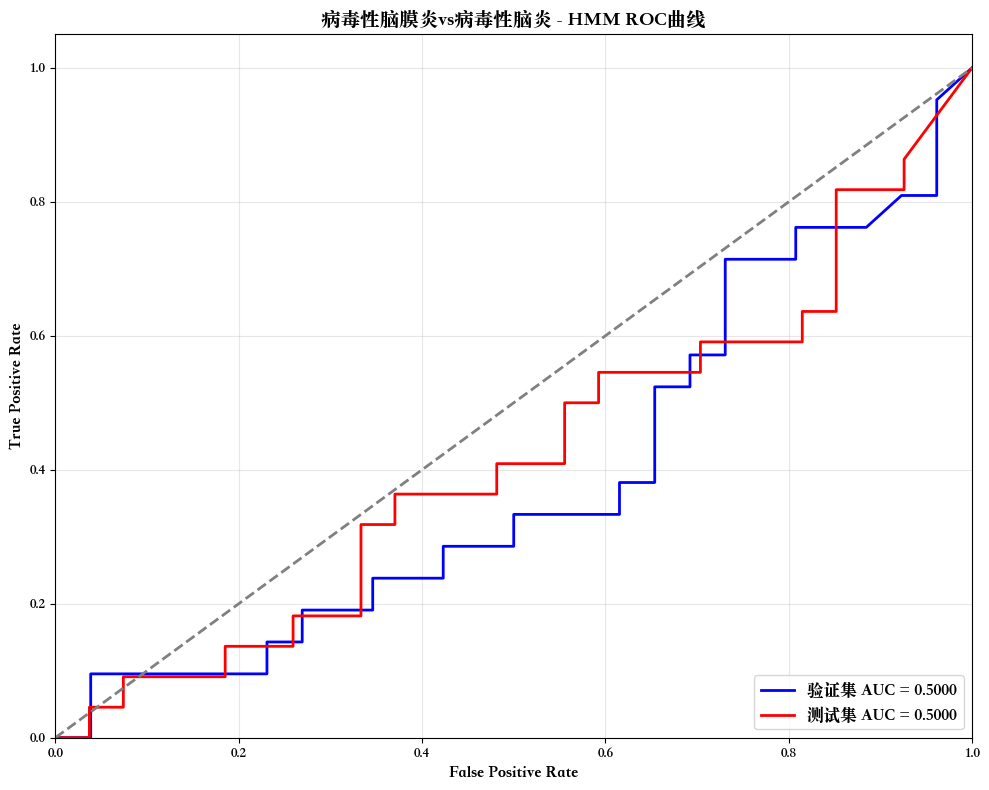

[I 2025-09-29 15:05:39,284] A new study created in memory with name: no-name-fee090be-2198-4177-84b5-8d2e6ec423f0
[I 2025-09-29 15:05:39,319] Trial 0 finished with value: 0.1932234432234432 and parameters: {'n_components': 5, 'covariance_type': 'full', 'n_iter': 73}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,329] Trial 1 finished with value: 0.5 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 196}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,372] Trial 2 finished with value: 0.228937728937729 and parameters: {'n_components': 9, 'covariance_type': 'spherical', 'n_iter': 129}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,405] Trial 3 finished with value: 0.5595238095238095 and parameters: {'n_components': 5, 'covariance_type': 'tied', 'n_iter': 105}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,461] Trial 4 finished with value: 0.3058608058608059 and parame

Index(['脑脊液_有核细胞计数_定量', '血_降钙素原_定量', '血_同型半胱氨酸_定量', '血_细胞.CD3+CD4+百分比_定量',
       '血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量'],
      dtype='object')
开始超参数优化...


[I 2025-09-29 15:05:39,504] Trial 6 finished with value: 0.21245421245421248 and parameters: {'n_components': 4, 'covariance_type': 'tied', 'n_iter': 124}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,513] Trial 7 finished with value: 0.5 and parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 128}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,548] Trial 8 finished with value: 0.4212454212454213 and parameters: {'n_components': 6, 'covariance_type': 'tied', 'n_iter': 185}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,599] Trial 9 finished with value: 0.3415750915750916 and parameters: {'n_components': 7, 'covariance_type': 'full', 'n_iter': 99}. Best is trial 0 with value: 0.1932234432234432.
[I 2025-09-29 15:05:39,635] Trial 10 finished with value: 0.3489010989010989 and parameters: {'n_components': 10, 'covariance_type': 'diag', 'n_iter': 51}. Best is trial 0 with value: 0.1932234432234432.


优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.8068
  Best params: 
    n_components: 5
    covariance_type: full
    n_iter: 73

使用最佳参数训练最终模型...

验证 集评估结果:
Accuracy: 0.4681
Precision: 0.4333
Recall: 0.6190
F1-Score: 0.5098
AUC: 0.5678

测试 集评估结果:
Accuracy: 0.5102
Precision: 0.4688
Recall: 0.6818
F1-Score: 0.5556
AUC: 0.5303

训练 集评估结果:
Accuracy: 0.5141
Precision: 0.4691
Recall: 0.5938
F1-Score: 0.5241
AUC: 0.5632


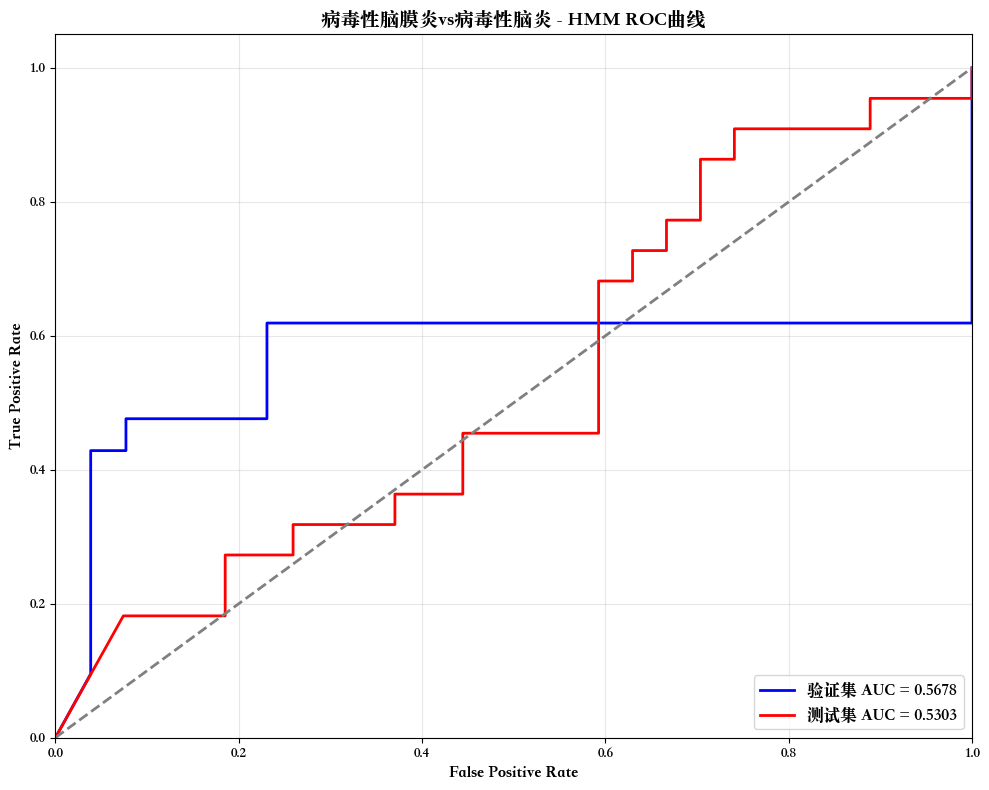

In [ ]:
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]
    print(X_1.columns)  
    
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到最优模型
    model_dict = train(X_train, y_train, X_val, y_val)

    # 评估验证集和测试集
    val_results = evaluate_model(model_dict, X_val, y_val, "验证")
    test_results = evaluate_model(model_dict, X_test, y_test, "测试")    
    train_results = evaluate_model(model_dict, X_train, y_train, "训练")    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, train_results, key, current_dataset)
    
    # # 特征重要性
    # X = pd.concat([X_1,X_2])
    # y = pd.concat([y_1,y_2])
    # n_features = X.shape[1]
    # importances = []
    
    # for i in range(n_features):
    #     # 去掉第 i 个特征
    #     X_new = np.delete(X, i, axis=1)
    #     model_dict = train(X_new, y, X_new, y)
    #     auc_new = evaluate_model(model_dict, X_new, y, "测试")['auc']
    #     drop = test_results['auc'] - auc_new
    #     importances.append((i, auc_new, drop))

    # # 排序
    # importances.sort(key=lambda x: x[2], reverse=True)

    # print("\nLOFO 特征重要性排序：")
    # for i, auc_new, drop in importances:
    #     features = list(X.columns)
    #     # print(features)
    #     print(f"特征 {features[i]}: 移除后 AUC={auc_new:.3f}, 下降={drop:.3f}")


    # 绘制HMM分析图
    # draw_hmm_analysis(model_dict, X_train, X_test, current_dataset, key)

if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎vs非感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    run_model(key, item, filtered_df2, current_dataset)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)